## **1. Introduction to the Weight-Height Dataset 💡**

In this lecture, we'll explore **Statistical Inference** using the **Weight-Height Dataset**. This dataset contains three key columns:

- **Gender**: Categorical variable indicating the gender of the individual.
- **Height**: Continuous variable representing the height .
- **Weight**: Continuous variable representing the weight .

We will treat this dataset as a **sample** from a larger population to demonstrate fundamental inference concepts such as **sampling**, **confidence intervals**, and the **Central Limit Theorem (CLT)**.

Let's start by loading and exploring the Weight-Height dataset.

In [1]:
import requests

url = "https://drive.google.com/uc?id=1Mrt008vkE4nVb1zE4f06_rtq70QPfkIo -O weight-height.csv"
filename = "weight-height.csv"

print(f"Downloading {filename}...")
response = requests.get(url)

if response.status_code == 200:
    with open(filename, "wb") as f:
        f.write(response.content)
    print("Download successful!")
else:
    print(f"Failed to download. Status code: {response.status_code}")

Failed to download. Status code: 404


In [2]:
!wget --no-check-certificate https://drive.google.com/uc?id=1Mrt008vkE4nVb1zE4f06_rtq70QPfkIo -O weight-height.csv

zsh:1: no matches found: https://drive.google.com/uc?id=1Mrt008vkE4nVb1zE4f06_rtq70QPfkIo


In [3]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Weight-Height dataset
df = pd.read_csv('weight-height.csv')

# Display the first few rows of the dataset
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


**Dataset Overview**

Let's take a quick look at the first few entries of our dataset:

- **Gender**: Indicates whether the individual is Male or Female.
- **Height**: Measured in centimeters.
- **Weight**: Measured in kilograms.

This dataset serves as our foundation for understanding how to generalize insights from a sample to a broader population.


In [4]:
# Basic statistical summary of the dataset
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


### Visualizing the Data

Before diving into statistical inference, it's helpful to visualize the distribution of heights and weights across different genders.


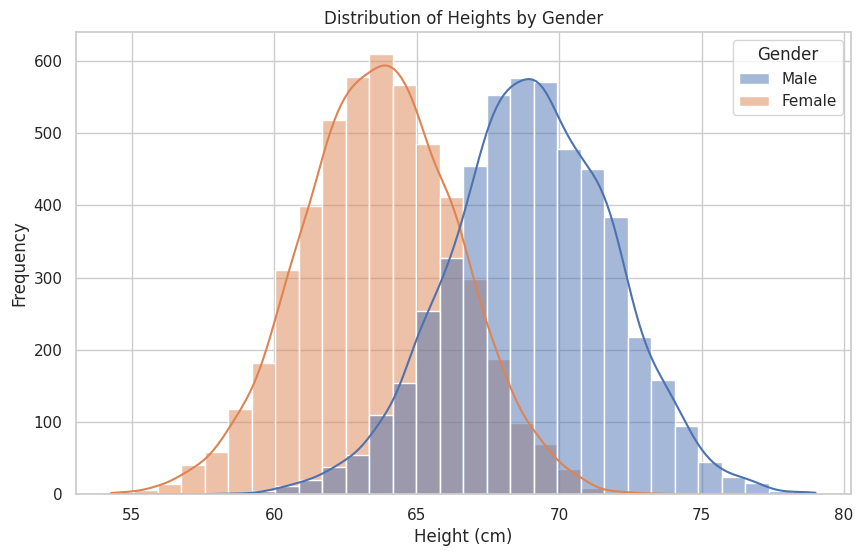

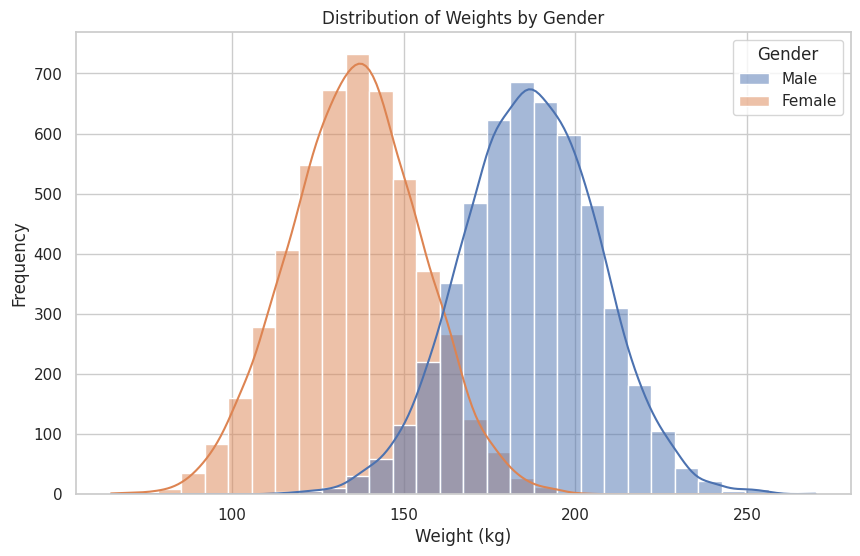

In [ ]:
# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Plot distribution of heights by gender
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Height', hue='Gender', kde=True, bins=30)
plt.title('Distribution of Heights by Gender')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.show()

# Plot distribution of weights by gender
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Weight', hue='Gender', kde=True, bins=30)
plt.title('Distribution of Weights by Gender')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.show()



---
## **2. Population vs. Sample 🔍**

Understanding the distinction between a **Population** and a **Sample** is fundamental in **Statistical Inference**. Let's break down these concepts and see how they apply to our **Weight-Height Dataset**.

### 📚 Population

- **Definition:** The entire group of individuals or instances about whom we want to draw conclusions.
- **Example:** If our **Weight-Height Dataset** includes data for every person in a specific country, it represents the **Population**.

### 🧩 Sample

- **Definition:** A subset of the population selected for analysis.
- **Example:** If our dataset contains data from a local survey of 1,000 individuals out of a country's population of 50 million, this dataset is a **Sample**.

### Applying to the Weight-Height Dataset

- **As a Population:** If the dataset encompasses all individuals in a defined group (e.g., all students in a university), we treat it as the **Population**.
  
- **As a Sample:** If the dataset represents a smaller group drawn from a larger population (e.g., a survey of employees in a company), it serves as a **Sample**.

💡 **Key Insight:** Most real-world datasets are **Samples** from a larger **Population**, allowing us to make inferences about the population based on sample data.

### Visualizing Population vs. Sample

Let's illustrate the difference by randomly selecting a **Sample** from our **Weight-Height Dataset** and comparing it to the entire **Population**.



In [ ]:
# Set a random seed for reproducibility
import numpy as np
np.random.seed(42)

# Define population size
population_size = len(df)

# Define sample size (e.g., 10% of the population)
sample_size = int(0.1 * population_size)

# Randomly sample without replacement
sample_df = df.sample(n=sample_size, random_state=42)

# Display the sample
sample_df.head()

,Gender,Height,Weight
6252,Female,68.687232,173.115813
4684,Male,68.829334,195.162042
1731,Male,66.398128,170.217451
4742,Male,71.929340,215.049660
4521,Male,67.042903,182.721452


**Comparing Population and Sample**

Let's compare the **mean height** and **mean weight** of the **Population** and the **Sample** to see how well the sample represents the population.


In [ ]:
# Calculate population statistics
population_mean_height = df['Height'].mean()
population_mean_weight = df['Weight'].mean()

# Calculate sample statistics
sample_mean_height = sample_df['Height'].mean()
sample_mean_weight = sample_df['Weight'].mean()

# Display the results
comparison_df = pd.DataFrame({
    'Statistic': ['Mean Height (cm)', 'Mean Weight (kg)'],
    'Population': [population_mean_height, population_mean_weight],
    'Sample': [sample_mean_height, sample_mean_weight]
})

comparison_df

,Statistic,Population,Sample
0,Mean Height (cm),66.367560,66.367945
1,Mean Weight (kg),161.440357,161.086441


**Interpretation**

- **Mean Height:**  
  - **Population:** 66.367560
  - **Sample:** 66.367945
  
- **Mean Weight:**  
  - **Population:** 161.44
  - **Sample:** 161.08

The **Sample** statistics are close to the **Population** statistics, indicating that the sample is a good representation of the population. However, slight differences are expected due to sampling variability.

---

## **3. Sample Statistics & Standard Error 📏**

Now that we've distinguished between a **Population** and a **Sample**, let's delve into **Sample Statistics** and understand the concept of **Standard Error**. These are foundational elements in **Statistical Inference** that allow us to summarize and make predictions about our data.

### 📊 Sample Statistics

**Sample Statistics** are numerical values that summarize and describe characteristics of a **Sample**. The primary sample statistics we will focus on are:

- **Mean ($ \bar{x} $)**: The average value.
- **Variance ($ s^2 $)**: Measures the spread of the data.
- **Standard Deviation ($ s $)**: The square root of variance, representing data dispersion.

### 🧮 Calculating Sample Statistics

Let's compute these statistics for both **Height** and **Weight** in our **Sample**.


In [ ]:
# Calculate sample statistics for Height
sample_mean_height = sample_df['Height'].mean()
sample_variance_height = sample_df['Height'].var()
sample_std_height = sample_df['Height'].std()

# Calculate sample statistics for Weight
sample_mean_weight = sample_df['Weight'].mean()
sample_variance_weight = sample_df['Weight'].var()
sample_std_weight = sample_df['Weight'].std()

# Create a DataFrame to display the sample statistics
sample_stats = pd.DataFrame({
    'Statistic': ['Mean', 'Variance', 'Standard Deviation'],
    'Height': [sample_mean_height, sample_variance_height, sample_std_height],
    'Weight': [sample_mean_weight, sample_variance_weight, sample_std_weight]
})

sample_stats

,Statistic,Height,Weight
0,Mean,66.367945,161.086441
1,Variance,14.655280,1027.816083
2,Standard Deviation,3.828221,32.059571


**Interpretation:**

- **Mean:** Represents the average height and weight in our sample.
- **Variance & Standard Deviation:** Indicate how much the heights and weights vary around the mean.

💡 **Key Insight:** Higher variance and standard deviation imply more variability in the data, while lower values indicate that the data points are closer to the mean.


### 🔍 Standard Error

The **Standard Error (SE)** quantifies the uncertainty in our sample statistic (e.g., the sample mean). It represents the standard deviation of the sampling distribution of the sample mean.

**Formula:**

$
SE = \frac{s}{\sqrt{n}}
$

Where:
- $ s $ = Sample Standard Deviation
- $ n $ = Sample Size

### 🧮 Calculating Standard Error

Let's compute the **Standard Error** for the **Mean Height** and **Mean Weight** in our sample.

In [ ]:
# Define sample size
n = len(sample_df)

# Calculate Standard Error for Height
se_height = sample_std_height / np.sqrt(n)

# Calculate Standard Error for Weight
se_weight = sample_std_weight / np.sqrt(n)

# Create a DataFrame to display the Standard Errors
standard_errors = pd.DataFrame({
    'Statistic': ['Standard Error'],
    'Height': [se_height],
    'Weight': [se_weight]
})

standard_errors

,Statistic,Height,Weight
0,Standard Error,0.121059,1.013813


**Interpretation:**

- **Standard Error of the Mean Height:** Indicates how much the sample mean height is expected to vary from the true population mean height.
- **Standard Error of the Mean Weight:** Indicates how much the sample mean weight is expected to vary from the true population mean weight.

💡 **Key Insight:** A smaller **Standard Error** suggests that the sample mean is a more accurate estimate of the population mean.

### 📈 Visualizing Sample Statistics

Understanding **Sample Statistics** and **Standard Error** is easier with visualization. Let's plot the distribution of sample means to see how they relate to the population parameters.

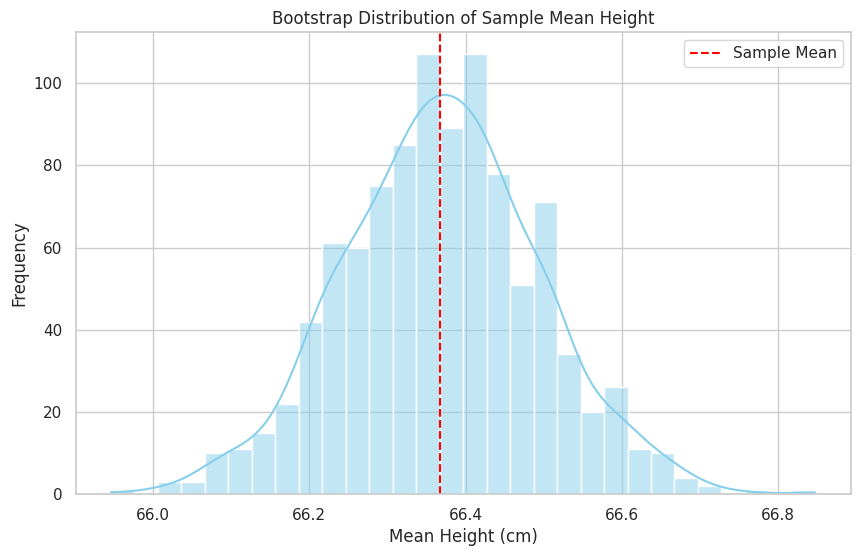

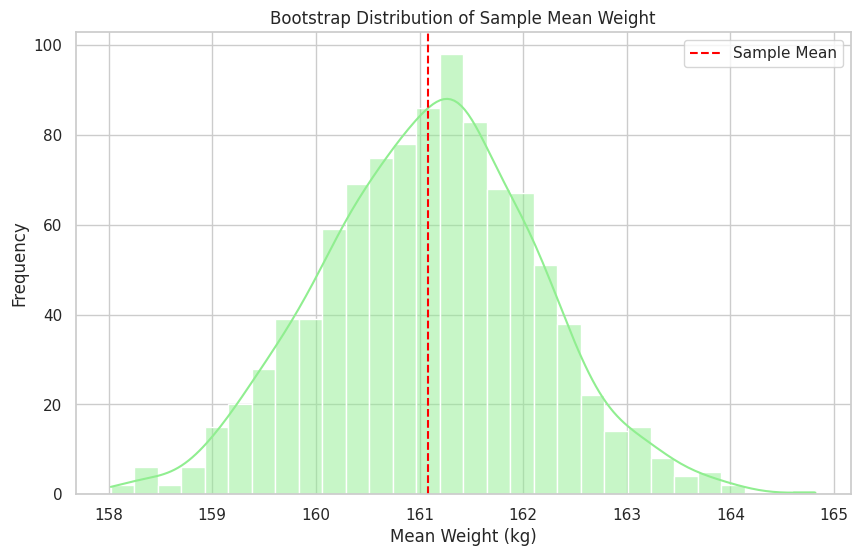

In [ ]:
# Number of bootstrap samples
num_bootstrap = 1000

# Initialize lists to store bootstrap sample means
bootstrap_means_height = []
bootstrap_means_weight = []

# Perform bootstrap sampling
for _ in range(num_bootstrap):
    bootstrap_sample = sample_df.sample(n=n, replace=True)
    bootstrap_means_height.append(bootstrap_sample['Height'].mean())
    bootstrap_means_weight.append(bootstrap_sample['Weight'].mean())

# Convert lists to Series
bootstrap_means_height = pd.Series(bootstrap_means_height)
bootstrap_means_weight = pd.Series(bootstrap_means_weight)

# Plot bootstrap distribution for Height
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_means_height, kde=True, color='skyblue', bins=30)
plt.axvline(sample_mean_height, color='red', linestyle='--', label='Sample Mean')
plt.title('Bootstrap Distribution of Sample Mean Height')
plt.xlabel('Mean Height (cm)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Plot bootstrap distribution for Weight
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_means_weight, kde=True, color='lightgreen', bins=30)
plt.axvline(sample_mean_weight, color='red', linestyle='--', label='Sample Mean')
plt.title('Bootstrap Distribution of Sample Mean Weight')
plt.xlabel('Mean Weight (kg)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

**Visualization of Sampling Distributions**

The above histograms represent the **Bootstrap Distributions** of the **Sample Mean Height** and **Sample Mean Weight**.

- The **red dashed line** indicates the **Sample Mean**.
- The spread of the distribution reflects the **Standard Error**.

💡 **Key Insight:** The **Standard Error** determines the width of the sampling distribution. Smaller **SE** leads to a narrower distribution, indicating more precise estimates of the population mean.



---



## **4. Central Limit Theorem (CLT) 🌐**

The **Central Limit Theorem (CLT)** is a cornerstone of **Statistical Inference**. It allows us to make inferences about population parameters even when the population distribution is not normal. Understanding the CLT is crucial for constructing **Confidence Intervals** and conducting **Hypothesis Testing**.

### 📚 What is the Central Limit Theorem?

**Central Limit Theorem (CLT):**  
*Regardless of the population distribution, the distribution of the sample means approaches a normal distribution as the sample size becomes large (typically $ n \geq 30 $).*

**Key Points:**

- **Sample Size ($ n $)**: Larger samples lead to a distribution of sample means that is more normally distributed.
- **Population Distribution**: Can be skewed, uniform, or any shape; CLT still applies to the distribution of sample means.
- **Mean of Sampling Distribution ($ \mu_{\bar{x}} $)**: Equal to the population mean ($ \mu $).
- **Standard Error ($ \sigma_{\bar{x}} $)**: Equal to the population standard deviation ($ \sigma $) divided by the square root of the sample size ($ n $).

💡 **Why CLT Matters:**  
It justifies the use of the **Normal Distribution** in many statistical procedures, even when the underlying data is not normally distributed.

### 🔍 Demonstrating CLT with the Weight-Height Dataset

Let's empirically demonstrate the **Central Limit Theorem** using our **Weight-Height Dataset**. We'll repeatedly take random samples from the dataset, compute their means, and observe the distribution of these sample means.

In [ ]:
# Import additional libraries if not already imported
import numpy as np

# Define parameters for the simulation
num_samples = 1000  # Number of samples to draw
sample_size = 30    # Size of each sample

# Initialize lists to store sample means
sample_means_height = []
sample_means_weight = []

# Perform the sampling
for _ in range(num_samples):
    # Randomly sample 'sample_size' observations without replacement
    sample = df.sample(n=sample_size, replace=False)
    # Calculate the mean of Height and Weight
    mean_height = sample['Height'].mean()
    mean_weight = sample['Weight'].mean()
    # Append to the lists
    sample_means_height.append(mean_height)
    sample_means_weight.append(mean_weight)

# Convert lists to pandas Series for easy handling
sample_means_height = pd.Series(sample_means_height)
sample_means_weight = pd.Series(sample_means_weight)

**Visualizing the Sampling Distribution of the Sample Means**

Now, let's plot the distribution of the sample means for **Height** and **Weight**. According to the **CLT**, these distributions should approximate a **Normal Distribution**.


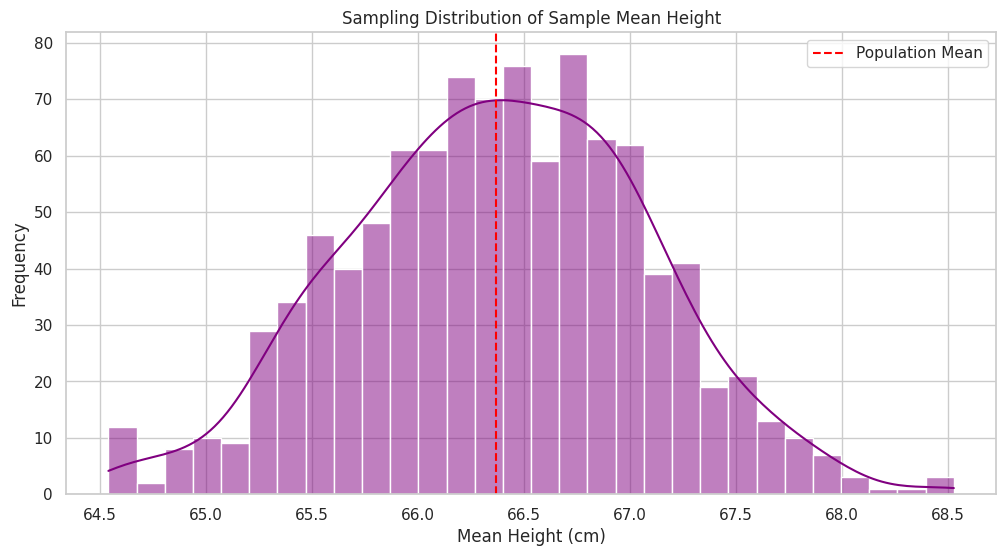

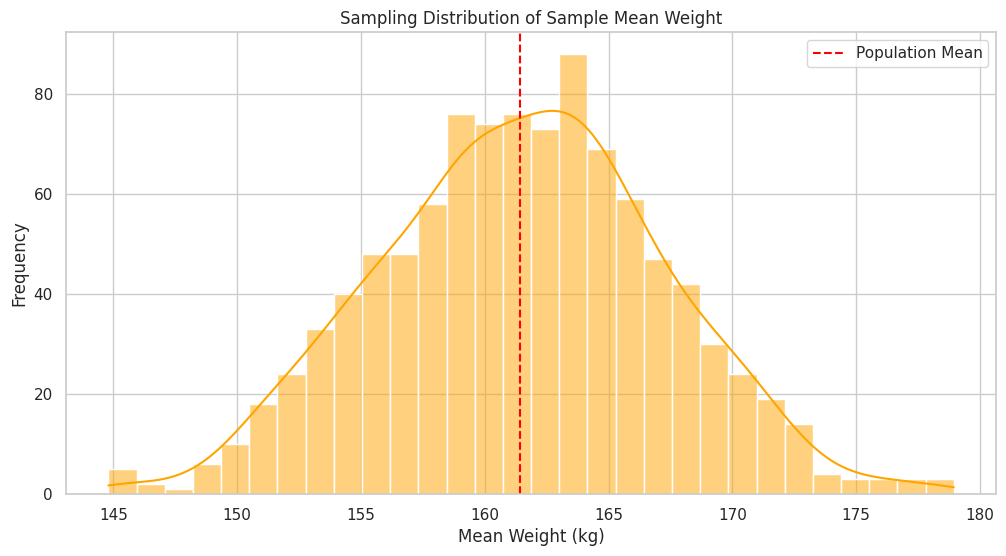

In [ ]:
# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Plot the sampling distribution for Mean Height
plt.figure(figsize=(12, 6))
sns.histplot(sample_means_height, kde=True, color='purple', bins=30)
plt.title('Sampling Distribution of Sample Mean Height')
plt.xlabel('Mean Height (cm)')
plt.ylabel('Frequency')
plt.axvline(df["Height"].mean(), color='red', linestyle='--', label='Population Mean')
plt.legend()
plt.show()

# Plot the sampling distribution for Mean Weight
plt.figure(figsize=(12, 6))
sns.histplot(sample_means_weight, kde=True, color='orange', bins=30)
plt.title('Sampling Distribution of Sample Mean Weight')
plt.xlabel('Mean Weight (kg)')
plt.ylabel('Frequency')
plt.axvline(df["Weight"].mean(), color='red', linestyle='--', label='Population Mean')
plt.legend()
plt.show()

### Interpretation of the Sampling Distributions

- **Shape of the Distribution:**  
  Both histograms of the sample means for **Height** and **Weight** appear approximately **Normal**, even if the original data distributions are not perfectly normal.

- **Central Tendency:**  
  The **red dashed line** represents the **Population Mean**. The center of the sampling distribution aligns closely with this mean, illustrating that the **Sample Means** are unbiased estimators of the **Population Mean**.

- **Spread of the Distribution:**  
  The spread of the sampling distribution is smaller than the spread of the original data, demonstrating the concept of **Standard Error**.

💡 **Key Insight:**  
The **Central Limit Theorem** enables us to assume a **Normal Distribution** for the sampling distribution of the mean, which is essential for constructing **Confidence Intervals** and performing **Hypothesis Tests**.

### 📈 Visual Comparison: Original Distribution vs. Sampling Distribution

To better understand the impact of CLT, let's compare the original **Height** distribution with the **Sampling Distribution of Sample Means**.


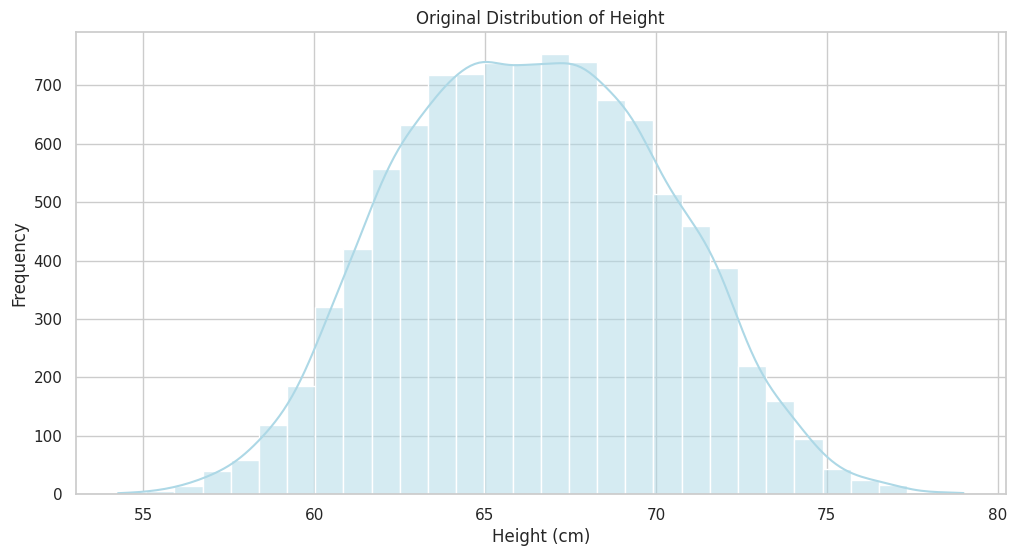

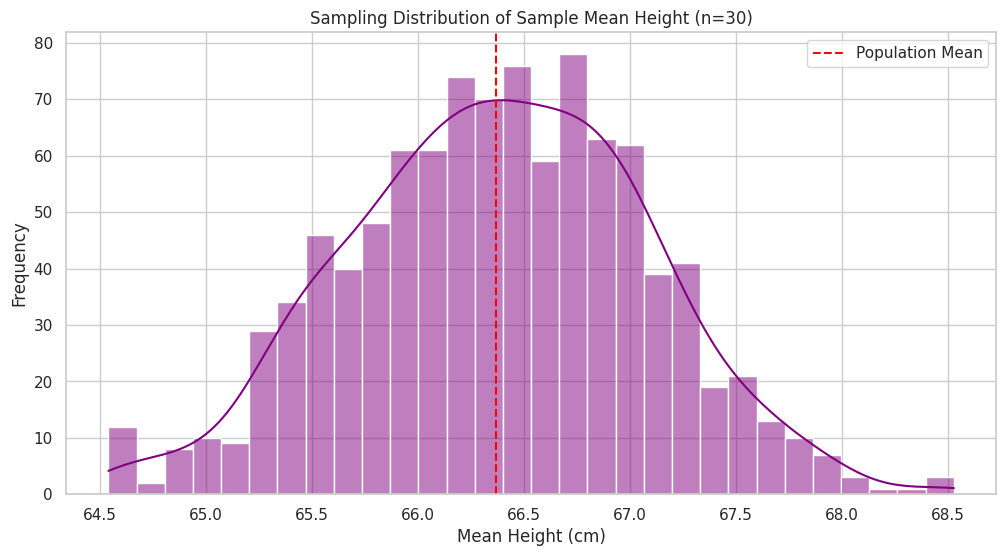

In [ ]:
# Plot original distribution of Height
plt.figure(figsize=(12, 6))
sns.histplot(df['Height'], kde=True, color='lightblue', bins=30)
plt.title('Original Distribution of Height')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.show()

# Plot sampling distribution of sample mean Height
plt.figure(figsize=(12, 6))
sns.histplot(sample_means_height, kde=True, color='purple', bins=30)
plt.title('Sampling Distribution of Sample Mean Height (n=30)')
plt.xlabel('Mean Height (cm)')
plt.ylabel('Frequency')
plt.axvline(df["Height"].mean(), color='red', linestyle='--', label='Population Mean')
plt.legend()
plt.show()

**Comparison Insights**

- **Original Distribution:**  
  The original **Height** distribution may be skewed or have multiple modes, depending on the dataset.

- **Sampling Distribution of the Mean:**  
  Regardless of the original distribution's shape, the **Sampling Distribution of the Mean** is approximately **Normal** due to the **CLT**.

💡 **Takeaway:**  
Even if the data does not follow a **Normal Distribution**, the distribution of the **Sample Means** will approximate normality as the sample size increases, allowing us to apply inferential statistics confidently.

---

## **5. Confidence Intervals (CIs) 📈**

Building on our understanding of **Sample Statistics** and the **Central Limit Theorem (CLT)**, we can now construct **Confidence Intervals (CIs)**. Confidence intervals provide a range of values within which we expect the **Population Parameter** (e.g., mean height or weight) to lie, with a certain level of confidence (commonly 95%).

### 📚 What is a Confidence Interval?

A **Confidence Interval** gives an estimated range of values which is likely to include an unknown population parameter. The interval has an associated confidence level that quantifies the level of confidence that the parameter lies within the interval.

**Key Components:**

- **Point Estimate ($ \bar{x} $)**: The sample mean.
- **Margin of Error (ME)**: The product of the critical value and the **Standard Error (SE)**.
- **Confidence Level**: The probability that the confidence interval contains the population parameter (e.g., 95%).

**Formula:**

$
\text{CI} = \bar{x} \pm z \times \left( \frac{s}{\sqrt{n}} \right)
$

Where:
- $ \bar{x} $ = Sample Mean
- $ z $ = Z-score corresponding to the desired confidence level (e.g., 1.96 for 95% CI)
- $ s $ = Sample Standard Deviation
- $ n $ = Sample Size

💡 **Why Confidence Intervals Matter:**  
They provide a range of plausible values for the population parameter, offering more information than a single point estimate.

### 🧮 Calculating Confidence Intervals Using CLT

Let's compute the **95% Confidence Interval** for the **Mean Height** and **Mean Weight** using our **Sample** from the **Weight-Height Dataset**.

In [ ]:
# Define confidence level
confidence_level = 0.95

# Calculate the z-score for the given confidence level
# For 95% CI, z-score is approximately 1.96
from scipy import stats

z_score = stats.norm.ppf(1 - (1 - confidence_level) / 2)

# Calculate Confidence Interval for Mean Height
ci_mean_height_lower = sample_mean_height - z_score * se_height
ci_mean_height_upper = sample_mean_height + z_score * se_height

# Calculate Confidence Interval for Mean Weight
ci_mean_weight_lower = sample_mean_weight - z_score * se_weight
ci_mean_weight_upper = sample_mean_weight + z_score * se_weight

# Create a DataFrame to display the Confidence Intervals
confidence_intervals = pd.DataFrame({
    'Statistic': ['Mean Height', 'Mean Weight'],
    'Lower Bound': [ci_mean_height_lower, ci_mean_weight_lower],
    'Upper Bound': [ci_mean_height_upper, ci_mean_weight_upper]
})

# Format the numerical values to two decimal places
confidence_intervals['Lower Bound'] = confidence_intervals['Lower Bound'].map('{:.2f}'.format)
confidence_intervals['Upper Bound'] = confidence_intervals['Upper Bound'].map('{:.2f}'.format)

confidence_intervals

,Statistic,Lower Bound,Upper Bound
0,Mean Height,66.13,66.61
1,Mean Weight,159.10,163.07


**Interpretation:**

- **Mean Height:** We are **95% confident** that the true population mean height lies between *66.13 and 66.61.
- **Mean Weight:** We are **95% confident** that the true population mean weight lies between 159.10 and 163.07.

💡 **Key Insight:**  
The **Confidence Interval** provides a range that, with a specified level of confidence, contains the true population mean. A wider interval indicates more uncertainty, while a narrower interval indicates more precision.

### 🛠️ Bootstrap Confidence Intervals

While the **CLT-based Confidence Intervals** rely on the assumption of normality of the sampling distribution, **Bootstrap Confidence Intervals** do not make such assumptions and can be used with smaller sample sizes or non-normal data distributions.

**Bootstrap Steps:**

1. **Resample** the data with replacement to create many bootstrap samples.
2. **Calculate** the sample mean for each bootstrap sample.
3. **Determine** the percentile-based confidence interval from the bootstrap distribution.

Let's compute the **Bootstrap 95% Confidence Interval** for the **Mean Height**.


In [ ]:
# Number of bootstrap samples
num_bootstrap = 1000

# Initialize list to store bootstrap sample means
bootstrap_means_height = []

# Perform bootstrap sampling
for _ in range(num_bootstrap):
    bootstrap_sample = sample_df['Height'].sample(n=n, replace=True)
    bootstrap_means_height.append(bootstrap_sample.mean())

# Convert to pandas Series
bootstrap_means_height = pd.Series(bootstrap_means_height)

# Calculate the 2.5th and 97.5th percentiles for the 95% CI
bootstrap_ci_lower = bootstrap_means_height.quantile(0.025)
bootstrap_ci_upper = bootstrap_means_height.quantile(0.975)

# Display the Bootstrap Confidence Interval
bootstrap_ci = pd.DataFrame({
    'Statistic': ['Mean Height (Bootstrap 95% CI)'],
    'Lower Bound': [bootstrap_ci_lower],
    'Upper Bound': [bootstrap_ci_upper]
})

bootstrap_ci

,Statistic,Lower Bound,Upper Bound
0,Mean Height (Bootstrap 95% CI),66.128127,66.595841


**Interpretation:**

We are **95% confident** that the true population mean height lies between 66.13 and 66.59 based on the bootstrap sampling method.

💡 **Key Insight:**  
**Bootstrap Confidence Intervals** provide a flexible alternative to **CLT-based CIs**, especially useful when the underlying data distribution is unknown or when dealing with small sample sizes.

---

## **6. Uniform Distribution ⚖️**

While our primary focus has been on the **Normal Distribution** and its role in **Statistical Inference**, it's beneficial to understand other fundamental distributions, such as the **Uniform Distribution**. This section provides a brief overview to broaden your understanding of different data distributions.

### 📚 What is a Uniform Distribution?

A **Uniform Distribution** is a type of probability distribution where all outcomes are equally likely. In other words, every interval of the same length within the distribution's range has the same probability of occurrence.

**Key Characteristics:**

- **Shape:** Rectangular, as all values within the range are equally probable.
- **Parameters:**
  - **Lower Bound ($ a $)**: The minimum possible value.
  - **Upper Bound ($ b $)**: The maximum possible value.
- **Probability Density Function (PDF):**

  $
  f(x) =
  \begin{cases}
  \frac{1}{b - a} & \text{for } a \leq x \leq b \\
  0 & \text{otherwise}
  \end{cases}
  $

### 🧮 Generating a Uniform Distribution Example

To illustrate the **Uniform Distribution**, let's create a simple example where we generate random data points within a specified range and visualize their distribution.

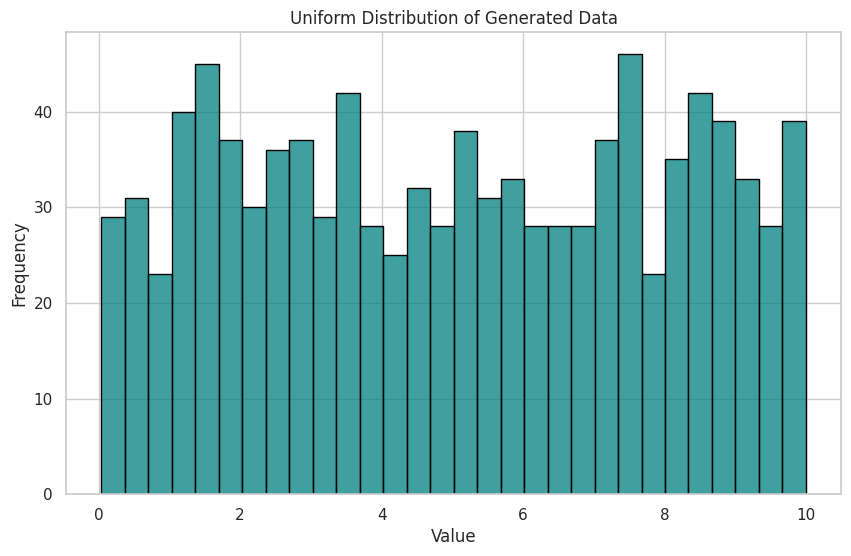

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Parameters for the Uniform Distribution
a = 0  # Lower bound
b = 10  # Upper bound
size = 1000  # Number of data points

# Generate random data following a Uniform Distribution
uniform_data = np.random.uniform(low=a, high=b, size=size)

# Convert to pandas Series for convenience
uniform_series = pd.Series(uniform_data)

# Plot the Uniform Distribution
plt.figure(figsize=(10, 6))
sns.histplot(uniform_series, bins=30, color='teal', edgecolor='black', kde=False)
plt.title('Uniform Distribution of Generated Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

**Visualization of the Uniform Distribution**

The histogram above displays a **Uniform Distribution** where each value between *0* and *10* is equally likely. Notice the rectangular shape, indicating that all intervals of the same length within the range have the same frequency.

💡 **Key Insight:**  
Unlike the **Normal Distribution**, where values cluster around the mean, the **Uniform Distribution** spreads values evenly across the entire range. Understanding different distributions is crucial for selecting appropriate statistical methods and models in data analysis.

### 🔍 Application in Real-World Data

While the **Uniform Distribution** is a fundamental concept, real-world data often follow more complex distributions. However, certain scenarios and simulations rely on uniform randomness, such as:

- **Random Sampling:** Ensuring each individual has an equal chance of being selected.
- **Simulation Models:** Generating random inputs for testing algorithms or systems.
- **Gaming and Cryptography:** Creating unbiased random events or keys.

💡 **Takeaway:**  
Recognizing and understanding various probability distributions, including the **Uniform Distribution**, equips you with the knowledge to model and analyze diverse datasets effectively.

---